In [1]:
import torch
from pathlib import Path
from IPython.display import Image
from random import sample
from collections import defaultdict
from PIL.Image import open as open_image, BILINEAR
import matplotlib.pyplot as plt
import numpy as np
import cv2
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torchvision
from torchvision import transforms
torch.cuda.empty_cache() 

In [13]:
username = 'alan'
data_dir = Path(f"/home/{username}/.cache/kagglehub/datasets/nexuswho/aitex-fabric-image-database/versions/1/")

defect_image_dir = data_dir / "Defect_images"
mask_image_dir = data_dir / "Mask_images"
no_defect_image_dir = data_dir / "NODefect_images"


pretrained_model_path = "best_model.pth"
pretrained_mlp_path = "best_mlp.pth"
height = 256
width = 1600
batch_size = 50
num_workers=3
epochs = 1

In [14]:
class_label_to_name = {
    2: 	"Broken end",
    6: 	"Broken yarn",
    10 :	"Broken pick",
    16 :	"Weft curling",
    19: 	"Fuzzyball",
    22: 	"Cut selvage",
    23: 	"Crease",
    25: 	"Warp ball",
    27: 	"Knots",
    29 :	"Contamination",
    30: 	"Nep",
    36: 	"Weft crack"
}
kept_classes = [10, 19, 30]
kept = ["Broken pick","Fuzzyball","Nep"]
unkept_classes = [2 , 6, 16,22,23,25,27,29,36]

unkept = ["Broken end","Broken yarn","Weft curling","Cut selvage","Crease","Warp ball","Knots","Contamination","Weft crack"]
# kept_classes = list(class_label_to_name.keys())

In [15]:

class UNetResNet18(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, decoder_mode="add", dropout=0.0):
        super().__init__()
        # Encoder backbone
        base = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
        del base.fc, base.avgpool  # UNet'te kullanılmıyor

        self.enc1 = nn.Sequential(base.conv1, base.bn1, base.relu)
        self.enc2 = nn.Sequential(base.maxpool, base.layer1)
        self.enc3 = base.layer2
        self.enc4 = base.layer3
        self.enc5 = base.layer4

        self.mode = decoder_mode

        def up_block(in_ch, out_ch, use_concat=False):
            layers = [nn.ConvTranspose2d(in_ch, out_ch, 2, 2),
                      nn.BatchNorm2d(out_ch),
                      nn.ReLU(inplace=True)]
            if dropout > 0:
                layers.append(nn.Dropout2d(p=dropout))
            if use_concat:
                layers += [nn.Conv2d(out_ch*2, out_ch, 3, padding=1),
                           nn.BatchNorm2d(out_ch),
                           nn.ReLU(inplace=True)]
            return nn.Sequential(*layers)

        if self.mode == "add":
            self.up4 = up_block(512,256)
            self.up3 = up_block(256,128)
            self.up2 = up_block(128,64)
            self.up1 = up_block(64,64)
        else:  # concat
            self.up4 = up_block(512,256, use_concat=True)
            self.up3 = up_block(256,128, use_concat=True)
            self.up2 = up_block(128,64, use_concat=True)
            self.up1 = up_block(64,64, use_concat=True)

        self.final = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        # Decoder
        if self.mode == "add":
            d4 = self.up4(e5) + e4
            d3 = self.up3(d4) + e3
            d2 = self.up2(d3) + e2
            d1 = self.up1(d2) + e1
        else:  # concat
            d4 = self.up4(torch.cat([F.interpolate(e5, size=e4.shape[2:], mode="bilinear", align_corners=False), e4],1))
            d3 = self.up3(torch.cat([F.interpolate(d4, size=e3.shape[2:], mode="bilinear", align_corners=False), e3],1))
            d2 = self.up2(torch.cat([F.interpolate(d3, size=e2.shape[2:], mode="bilinear", align_corners=False), e2],1))
            d1 = self.up1(torch.cat([F.interpolate(d2, size=e1.shape[2:], mode="bilinear", align_corners=False), e1],1))

        out = self.final(d1)
        out = F.interpolate(out, size=x.shape[2:], mode="bilinear", align_corners=False)
        return out
        
    def encode(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        return self.enc5(x)

load model

In [16]:
model_dict = torch.load(pretrained_model_path, weights_only=False)
unet_model = UNetResNet18().cuda()
unet_model.load_state_dict(model_dict)
unet_model.eval()
print()

load data

In [17]:
from zlib import crc32
from torch.utils.data import Dataset, DataLoader

class FabricDefectDataset(Dataset):
    def __init__(self, defect_dir: Path, no_defect_dir: Path, mask_dir: Path, transforms=None, training=True, train_split = 0.8, censor_files = False, limited_classes = []):
        self.defect_dir = defect_dir
        self.all_classes = kept_classes+unkept_classes if not censor_files else kept_classes
        self.no_defect_dir = no_defect_dir
        self.mask_dir = mask_dir
        all_files = [path for path in defect_dir.glob("**/*.png") ]
        self.all_is_file_defect = [True] * len(list(defect_dir.glob("*.png")))
        all_files += [path for path in no_defect_dir.glob("**/*.png")]
        self.all_is_file_defect += [False] * len(list(no_defect_dir.glob("**/*.png")))
        self.files = []
        self.is_file_defect = []
        self.classes = []
        counts = defaultdict(int)
        for i, file in enumerate(all_files):
            
            hash_value = float(crc32(file.name.encode()) & 0xffffffff) / 2**32
            class_label = int(file.name.split("_")[1])
            if class_label not in kept_classes:
                hash_value = 1.0
                
            if len(limited_classes)>0 and class_label in limited_classes and counts[self.all_classes.index(class_label)+1] > 0: 
                continue
            part_of_dataset = (
                (hash_value < train_split and training) 
                or (hash_value >= train_split and not training)
            )
            image_id = int(file.name.split("_")[0])
            if part_of_dataset:
                class_label = int(file.name.split("_")[1])
                if class_label not in kept_classes and censor_files:
                    continue
                if class_label in kept_classes or not self.all_is_file_defect[i] or not training:
                    self.files.append(file)
                    if self.all_is_file_defect[i]:
                        self.classes.append(self.all_classes.index(class_label)+1 ) 
                        counts[self.all_classes.index(class_label)+1] += 1
                    else:
                        self.classes.append(0)
                        counts[0] += 1
        self.transforms = transforms
        

    def __len__(self):
        return len(self.files)

    def _read_image(self, image_file):
        img = cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(image_id)
        return img

    def _build_mask(self, index):
        image_file = self.files[index]
        class_id = image_file.name.split()
        is_defect = self.is_file_defect[index]
        if is_defect:
            class_id = image_file.name.split("_")[1]
            mask_file_matches = list(self.mask_dir.glob(f"*_{class_id}_*"))
            mask_file_match = mask_file_matches[0]
            img = cv2.imread(str(mask_file_match), cv2.IMREAD_GRAYSCALE)
            return img
        else:
            img = cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE)
            return np.zeros_like(img)
            
    def __getitem__(self, idx):
        image_file = self.files[idx]
        img = np.repeat(self._read_image(image_file)[None,...], 3, axis=0)
        img = torch.from_numpy(img).float() / 255.0
        if self.transforms:
            
            img = self.transforms(img)
            
            img = transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))(img)
        else:
            img = torch.from_numpy(img[None,...]).float()
            img = transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))(img)
        class_ = self.classes[idx]
        meta = {"idx": idx}
        return img, class_, meta


# --- Collate function ---
def collate_fn(batch):
    images, classes, metas = zip(*batch)
    images = torch.stack(images)
    classes = torch.stack(classes)
    return images, classes, metas

In [18]:

def get_valid_transforms(H=height, W=width):
    return transforms.Compose([
        transforms.Resize((H, W),interpolation=BILINEAR),
    ])


In [36]:
train_ds =  FabricDefectDataset(
    defect_dir=defect_image_dir, 
    no_defect_dir=no_defect_image_dir, 
    mask_dir=mask_image_dir, 
    transforms=get_valid_transforms(), 
    training=True,
    train_split=0.7,
    censor_files=True
)
train_loader   = DataLoader(train_ds,   batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)


val_ds =  FabricDefectDataset(
    defect_dir=defect_image_dir, 
    no_defect_dir=no_defect_image_dir, 
    mask_dir=mask_image_dir, 
    transforms=get_valid_transforms(), 
    training=False,
    train_split=0.7,
    censor_files=True
)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

Counter({2: 30, 3: 9, 1: 7})
Counter({2: 9, 3: 5, 1: 3})


Text(0, 0.5, 'Number of Samples')

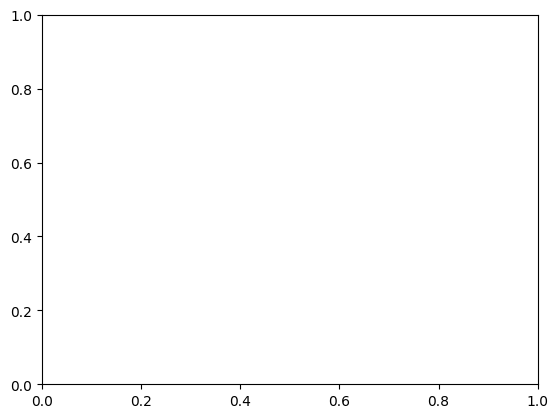

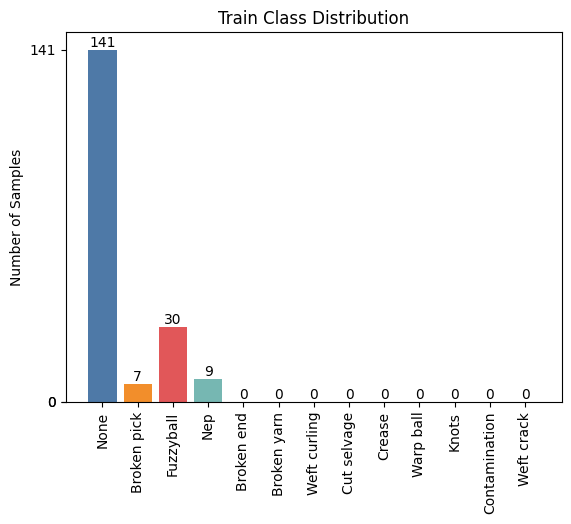

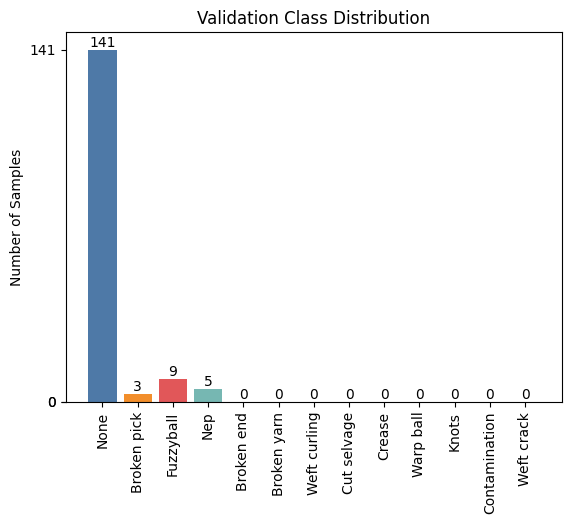

In [37]:
from collections import Counter
all_classes = ["None"]+kept_classes+unkept_classes
data = Counter(train_ds.classes)
print(data)

positions = np.arange(1, len(all_classes)+1, 1)
ax = plt.subplot(111)
values = [0 for i in range(len(all_classes))]
for i,c in enumerate(all_classes):
    values[i] = data[i]
values[0] = len(train_ds.all_is_file_defect) - sum(train_ds.all_is_file_defect)
colors = [
    "#4E79A7",  # blue
    "#F28E2B",  # orange
    "#E15759",  # red
    "#76B7B2",  # teal
    "#59A14F",  # green
]
    
fig, ax = plt.subplots()

bar_container = ax.bar(positions, values, color=colors)
ax.bar_label(bar_container, fmt='{:,.0f}')

ax.set_xticks(positions)
ax.set_yticks([0, min(values), max(values)])
ax.set_xticklabels(["None"]+kept+unkept, rotation=90)
ax.set_title("Train Class Distribution")
plt.ylabel("Number of Samples")


data = Counter(val_ds.classes)
print(data)
positions = np.arange(1, len(all_classes)+1, 1)
values = [0 for i in range(len(all_classes))]
for i,c in enumerate(all_classes):
    values[i] = data[i]
values[0] = len(val_ds.all_is_file_defect) - sum(val_ds.all_is_file_defect)

ax = plt.subplot(111)

colors = [
    "#4E79A7",  # blue
    "#F28E2B",  # orange
    "#E15759",  # red
    "#76B7B2",  # teal
    "#59A14F",  # green
]
fig, ax = plt.subplots()

bar_container = ax.bar(positions, values, color=colors)
ax.bar_label(bar_container, fmt='{:,.0f}')




ax.set_xticks(positions)
ax.set_yticks([0, min(values), max(values)])
ax.set_xticklabels(["None"]+kept+unkept, rotation=90)
ax.set_title("Validation Class Distribution")
plt.ylabel("Number of Samples")


In [39]:


mlp = torchvision.ops.MLP(
    in_channels=204800, 
    hidden_channels=[256, 4], 
    activation_layer=torch.nn.modules.activation.ReLU, 
    bias= True, dropout= 0.001).cuda()
mlp.cuda()
pos_weight = torch.ones([4]).cuda()  # All weights are equal to 1
pos_weight[1] = 141/7
pos_weight[2] = 141/30
pos_weight[3] = 141/9
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(mlp.parameters(), lr=0.001, weight_decay=0.005)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

In [40]:
val_scores = []
val_losses = []
training_losses = []
best_score = 0
model_file = "best_mlp.pth"
for epoch in range(100):
    # Run through training:
    print(f"epoch: {epoch}")
    train_loss_total = 0
    train_num_batches = 0
    for images, dense_classes, metas in train_loader:
        classes = torch.nn.functional.one_hot(dense_classes, num_classes=4).float().to('cuda')
        embeddings = unet_model.encode(images.cuda())
        embeddings = embeddings.reshape(len(embeddings), -1)
        optimizer.zero_grad()
        domain_embedded = mlp(embeddings.cuda())
        loss = criterion(domain_embedded, classes)
        train_loss_total += loss.sum().item()
        train_num_batches += 1
        
        loss.backward()
        optimizer.step()
    # validate
    training_losses.append(train_loss_total/train_num_batches)
    mlp.eval()
    val_score = 0
    val_loss = 0
    num_val_batches = 0
    for images, dense_classes, metas in val_loader:
        classes = torch.nn.functional.one_hot(dense_classes, num_classes=4).float().to('cuda')
        embeddings = unet_model.encode(images.cuda())
        embeddings = embeddings.reshape(len(embeddings), -1)
        domain_embedded = mlp(embeddings.cuda())
        # loss = criterion(domain_embedded, classes)
        # l2_lambda = 0.0000001
        # l2_reg = torch.tensor(0.).cuda()
        # for param in mlp.parameters():
        #     l2_reg += torch.norm(param)
        # loss += l2_lambda * l2_reg
        
        val_loss += loss.sum().item()
        domain_embedded = (domain_embedded > 0.5) 
        score = f1_score(
            torch.nn.functional.one_hot(dense_classes, num_classes=4).cpu().detach(), 
            domain_embedded.cpu().detach(),
            average='micro'
        )
        num_val_batches += 1
        val_score += score

    val_losses.append(val_loss/ num_val_batches)
    val_scores.append(val_score / num_val_batches)
    print(f"Train Loss (BCE + lambda * L2): {train_loss_total / train_num_batches}")
    print(f"Validation Loss (BCE + lambda * L2): {val_loss/ num_val_batches}")
    print(f"Validation Score (F1 micro score): {val_score / num_val_batches}")
    mlp.train()
    if val_score / num_val_batches > best_score:
        best_score = val_score / num_val_batches
        torch.save(mlp, model_file)

epoch: 0
Train Loss (BCE + lambda * L2): 2.1226508617401123
Validation Loss (BCE + lambda * L2): 2.1226508617401123
Validation Score (F1 micro score): 0.5
epoch: 1
Train Loss (BCE + lambda * L2): 5.059244155883789
Validation Loss (BCE + lambda * L2): 5.059244155883789
Validation Score (F1 micro score): 0.576271186440678
epoch: 2
Train Loss (BCE + lambda * L2): 3.1565818786621094
Validation Loss (BCE + lambda * L2): 3.1565818786621094
Validation Score (F1 micro score): 0.6363636363636364
epoch: 3
Train Loss (BCE + lambda * L2): 2.779249429702759
Validation Loss (BCE + lambda * L2): 2.779249429702759
Validation Score (F1 micro score): 0.6190476190476191
epoch: 4
Train Loss (BCE + lambda * L2): 1.657014012336731
Validation Loss (BCE + lambda * L2): 1.657014012336731
Validation Score (F1 micro score): 0.6274509803921569
epoch: 5
Train Loss (BCE + lambda * L2): 1.1143194437026978
Validation Loss (BCE + lambda * L2): 1.1143194437026978
Validation Score (F1 micro score): 0.6530612244897959
ep

KeyboardInterrupt: 

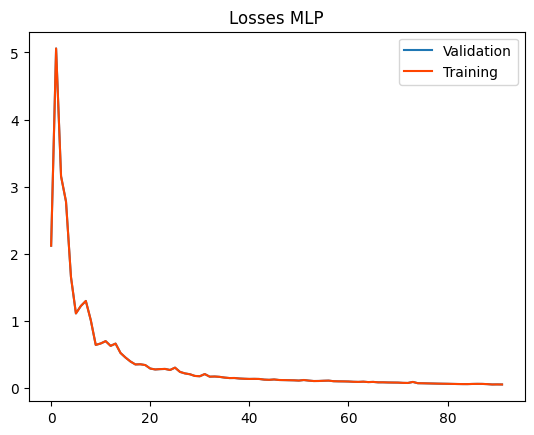

In [41]:
plt.plot(np.arange(len(val_losses)), val_losses, label="Validation")
plt.plot(np.arange(len(training_losses)), training_losses, label="Training", color="orangered")
plt.title("Losses MLP")
plt.legend()

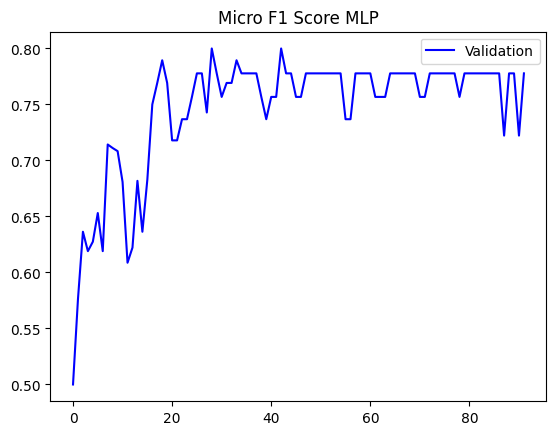

In [42]:
plt.plot(np.arange(len(val_scores)), val_scores, label="Validation", color="blue")
plt.title("Micro F1 Score MLP")
plt.legend()

In [43]:
total_val_ds =  FabricDefectDataset(
    defect_dir=defect_image_dir, 
    no_defect_dir=no_defect_image_dir, 
    mask_dir=mask_image_dir, 
    transforms=get_valid_transforms(), 
    training=False,
    train_split=0.5,
    censor_files=False,
    limited_classes=[]
)
total_val_loader   = DataLoader(total_val_ds,   batch_size=30, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
censored_val_ds =  FabricDefectDataset(
    defect_dir=defect_image_dir, 
    no_defect_dir=no_defect_image_dir, 
    mask_dir=mask_image_dir, 
    transforms=get_valid_transforms(), 
    training=False,
    train_split=0.5,
    censor_files=False,
    limited_classes=[16]
)
censored_val_loader   = DataLoader(censored_val_ds,   batch_size=30, shuffle=True,
                          num_workers=num_workers, pin_memory=True)

Counter({0: 141, 2: 21, 7: 9, 4: 9, 5: 8, 3: 7, 1: 6, 9: 6, 8: 5, 6: 3, 11: 1, 12: 1, 10: 1})
Counter({0: 141, 2: 21, 7: 9, 4: 9, 5: 8, 3: 7, 1: 6, 9: 6, 8: 5, 6: 1, 11: 1, 12: 1, 10: 1})


Text(0, 0.5, 'Number of Samples')

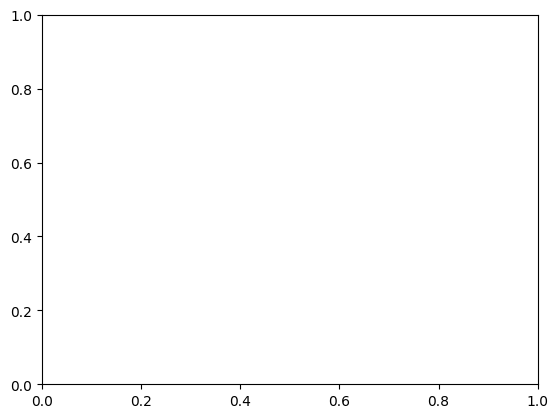

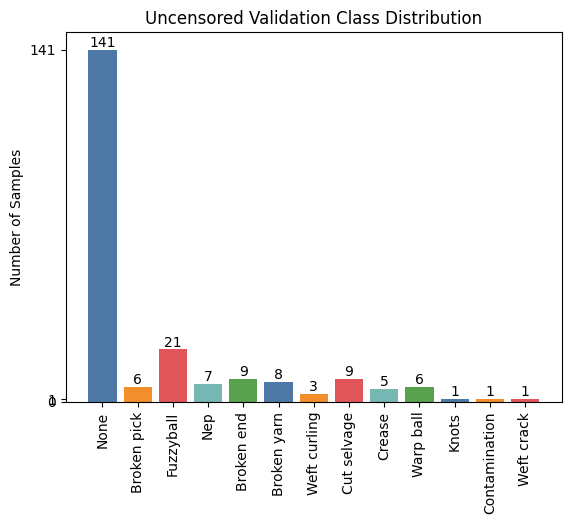

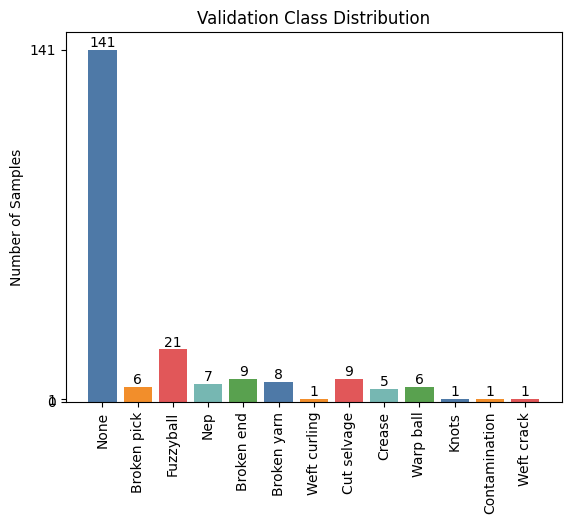

In [44]:
from collections import Counter
all_classes = ["None"]+kept_classes+unkept_classes
data = Counter(total_val_ds.classes)
print(data)

positions = np.arange(1, len(all_classes)+1, 1)
ax = plt.subplot(111)
values = [0 for i in range(len(all_classes))]
for i,c in enumerate(all_classes):
    values[i] = data[i]
values[0] = len(total_val_ds.all_is_file_defect) - sum(total_val_ds.all_is_file_defect)
colors = [
    "#4E79A7",  # blue
    "#F28E2B",  # orange
    "#E15759",  # red
    "#76B7B2",  # teal
    "#59A14F",  # green
]
    
fig, ax = plt.subplots()

bar_container = ax.bar(positions, values, color=colors)
ax.bar_label(bar_container, fmt='{:,.0f}')

ax.set_xticks(positions)
ax.set_yticks([0, min(values), max(values)])
ax.set_xticklabels(["None"]+kept+unkept, rotation=90)
ax.set_title("Uncensored Validation Class Distribution")
plt.ylabel("Number of Samples")


data = Counter(censored_val_ds.classes)
print(data)
positions = np.arange(1, len(all_classes)+1, 1)
values = [0 for i in range(len(all_classes))]
for i,c in enumerate(all_classes):
    values[i] = data[i]
values[0] = len(censored_val_ds.all_is_file_defect) - sum(censored_val_ds.all_is_file_defect)

ax = plt.subplot(111)

colors = [
    "#4E79A7",  # blue
    "#F28E2B",  # orange
    "#E15759",  # red
    "#76B7B2",  # teal
    "#59A14F",  # green
]
fig, ax = plt.subplots()

bar_container = ax.bar(positions, values, color=colors)
ax.bar_label(bar_container, fmt='{:,.0f}')
ax.set_xticks(positions)
ax.set_yticks([0, min(values), max(values)])
ax.set_xticklabels(["None"]+kept+unkept, rotation=90)
ax.set_title("Validation Class Distribution")
plt.ylabel("Number of Samples")

In [ ]:
# Loop through uncensored data collecting embeddings from unet&mlp

del unet_model

Traceback (most recent call last):
  File "/home/alan/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/home/alan/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/home/alan/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


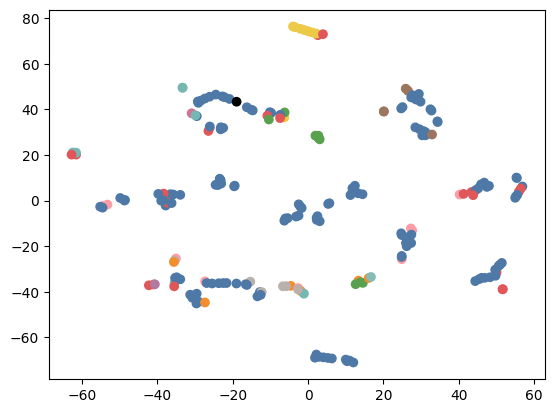

In [45]:
model_dict = torch.load(pretrained_model_path, weights_only=False)
unet_model = UNetResNet18().cuda()
unet_model.load_state_dict(model_dict)
unet_model = unet_model.eval()
print()
mlp = torch.load(pretrained_mlp_path, weights_only=False)
mlp = mlp.eval()
linear_layer = list(mlp.children())[0]
del mlp
print()
from sklearn.manifold import TSNE
# make forward
class FewShotFaultDetector(nn.Module):
    def __init__(self, censored_data: DataLoader, distance_metric = "l2_norm"):
        super().__init__()
        self.distance_metric = distance_metric

        model_dict = torch.load(pretrained_model_path, weights_only=False)
        self.centroids = dict()
        all_points = []
        colors = []
        color_choices = [
        "#4E79A7",  # blue
        "#F28E2B",  # orange
        "#E15759",  # red
        "#76B7B2",  # teal
        "#59A14F",  # green
        "#EDC948",  # yellow
        "#B07AA1",  # purple
        "#FF9DA7",  # pink
        "#9C755F",  # brown
        "#BAB0AC",  # gray
        "#86BCB6",  # light teal
        "#D37295",   # magenta
        "#000000"   # magenta
        ]
        centroid_counts = defaultdict(int)
        # Calculate centroids of each class
        for images, dense_classes, metas in censored_data:
            embeddings = unet_model.encode(images.cuda())
            embeddings = embeddings.reshape(len(embeddings), -1)
            domain_embedded = linear_layer(embeddings).cpu().detach()
            for individual_class, embedding in zip(dense_classes, domain_embedded):
                colors.append(color_choices[individual_class])
                if individual_class not in self.centroids:
                    self.centroids[individual_class] = embedding
                else:
                    self.centroids[individual_class] += embedding
                all_points.append(embedding)
                centroid_counts[individual_class] += 1
        all_points = torch.stack(all_points)
        X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(all_points)
        plt.scatter(X_embedded[:,0],X_embedded[:,1], color=colors)
        plt.show()
        
        
        # Normalize centroids
        for individual_class in self.centroids:
            self.centroids[individual_class] /= centroid_counts[individual_class]


    def forward(self, x):
        if len(x)!=1:
            x = x[None]
        embeddings = unet_model.encode(x.cuda())
        embeddings = embeddings.reshape(len(embeddings), -1)
        domain_embedded = linear_layer(embeddings).cpu().detach()
        predicted_classes = []
        for embedding in domain_embedded:
            curr_dist = math.inf if self.distance_metric == "l2_norm" else -1
            predicted_class = -1
            
            for class_ind, centroid in self.centroids.items():
                    
                if self.distance_metric == "l2_norm":
                    if (centroid - embedding).norm() < curr_dist:
                        curr_dist = (centroid - embedding).norm()
                        predicted_class = class_ind
                else:
                    cosi = torch.nn.CosineSimilarity(dim=0)
                    cos_output = cosi(centroid, embedding)
                    if cos_output > curr_dist:
                        curr_dist = cos_output
                        predicted_class = class_ind
            predicted_classes.append(predicted_class)  
        return predicted_classes

    def evaluate(self, class_ind: int, uncensored_data: DataLoader):
        total = 0
        correct = 0
        for images, dense_classes, metas in uncensored_data:
            predicted_classes = self.forward(images)
            for actual, predicted in zip(dense_classes, predicted_classes):
                if actual == class_ind:
                    total += 1
                    # Record this
                    if predicted == actual:
                        correct += 1
        return correct / total
few_shot_detector = FewShotFaultDetector(censored_val_loader)

In [46]:
model_dict = torch.load(pretrained_model_path, weights_only=False)
unet_model = UNetResNet18().cuda()
unet_model.load_state_dict(model_dict)
unet_model = unet_model.eval()
print()
mlp = torch.load(pretrained_mlp_path, weights_only=False)
mlp = mlp.eval()
linear_layer = list(mlp.children())[0]

import torch.nn as nn
 
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=5.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
 
    def forward(self, output1, output2, label):
        euclidean_distance = nn.functional.pairwise_distance(output1, output2)
        loss_contrastive = torch.mean((1 - label) * torch.pow(euclidean_distance, 2) +
                                      (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive



criterion = ContrastiveLoss()
optimizer = Adam(linear_layer.parameters(), lr=0.0001, weight_decay=0.003)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

In [47]:


training_losses = []
best_score = 0
model_file = "best_contrastive_layer.pth"
for epoch in range(100):
    # Run through training:
    print(f"epoch: {epoch}")
    train_loss_total = 0
    train_num_batches = 0
    for images, dense_classes, metas in censored_val_loader:
        if len(images) % 2 != 0:
            continue
            
        embeddings = unet_model.encode(images.cuda())
        embeddings = embeddings.reshape(len(embeddings), -1)
        domain_embedded = linear_layer(embeddings.cuda())
        optimizer.zero_grad()
        x_1 = domain_embedded[0::2]
        x_2 = domain_embedded[1::2]
        label = (dense_classes[0::2] != dense_classes[1::2]).float().cuda()
        loss = criterion(x_1,x_2,label)
        training_losses.append(loss.sum().item())
        train_num_batches += 1
        # l2_lambda = 0.1
        # l2_reg = torch.tensor(0.).cuda()
        # for param in mlp.parameters():
        #     l2_reg += torch.norm(param)
        # loss += l2_lambda * l2_reg
        loss.backward()
        optimizer.step()
    # validate
    # mlp.eval()
    val_score = 0
    val_loss = 0
    # num_val_batches = 0


    # val_losses.append(val_loss/ num_val_batches)
    # val_scores.append(val_score / num_val_batches)
    print(f"Train Loss (BCE + lambda * L2): {training_losses[-1]}")
    # print(f"Validation Score (F1 micro score): {val_score / num_val_batches}")
    # mlp.train()
    if training_losses[-1] > best_score:
        best_score = train_loss_total / train_num_batches
        torch.save(linear_layer, model_file)

epoch: 0
Train Loss (BCE + lambda * L2): 9963.265625
epoch: 1
Train Loss (BCE + lambda * L2): 0.0
epoch: 2
Train Loss (BCE + lambda * L2): 4735.701171875
epoch: 3
Train Loss (BCE + lambda * L2): 313.4826965332031
epoch: 4
Train Loss (BCE + lambda * L2): 0.0
epoch: 5
Train Loss (BCE + lambda * L2): 716.902587890625
epoch: 6
Train Loss (BCE + lambda * L2): 256.1640319824219
epoch: 7
Train Loss (BCE + lambda * L2): 26.987218856811523
epoch: 8
Train Loss (BCE + lambda * L2): 304.62384033203125
epoch: 9
Train Loss (BCE + lambda * L2): 116.94851684570312
epoch: 10
Train Loss (BCE + lambda * L2): 0.0
epoch: 11
Train Loss (BCE + lambda * L2): 73.19647979736328
epoch: 12
Train Loss (BCE + lambda * L2): 32.16081619262695
epoch: 13


KeyboardInterrupt: 

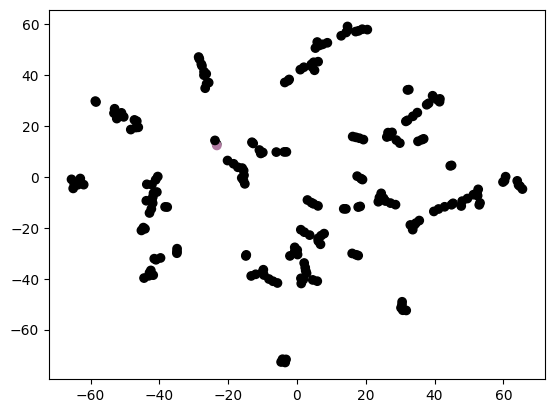

In [54]:
import math
pretrained_contrastive_path = "best_contrastive_layer.pth"
model_dict = torch.load(pretrained_model_path, weights_only=False)
unet_model = UNetResNet18().cuda()
unet_model.load_state_dict(model_dict)
unet_model = unet_model.eval()

mlp = torchvision.ops.MLP(
    in_channels=204800, 
    hidden_channels=[256, 4], 
    activation_layer=torch.nn.modules.activation.ReLU, 
    bias= True, dropout= 0.001).cuda()

linear_layer = list(mlp.children())[0]
linear_layer = torch.load(pretrained_contrastive_path, weights_only=False)


del mlp
print()
from sklearn.manifold import TSNE
# make forward
class FewShotFaultDetector(nn.Module):
    def __init__(self, censored_data: DataLoader, distance_metric = "l2_norm"):
        super().__init__()
        self.distance_metric = distance_metric

        model_dict = torch.load(pretrained_model_path, weights_only=False)
        self.centroids = dict()
        all_points = []
        colors = []
        color_choices = [
        "#4E79A7",  # blue
        "#F28E2B",  # orange
        "#E15759",  # red
        "#76B7B2",  # teal
        "#59A14F",  # green
        "#EDC948",  # yellow
        "#B07AA1",  # purple
        "#FF9DA7",  # pink
        "#9C755F",  # brown
        "#BAB0AC",  # gray
        "#86BCB6",  # light teal
        "#D37295",   # magenta
        "#000000"   # magenta
        ]
        centroid_counts = defaultdict(int)
        # Calculate centroids of each class
        for images, dense_classes, metas in censored_data:
            embeddings = unet_model.encode(images.cuda())
            embeddings = embeddings.reshape(len(embeddings), -1)
            domain_embedded = linear_layer(embeddings).cpu().detach()
            for individual_class, embedding in zip(dense_classes, domain_embedded):
                if individual_class == 6:
                    colors.append(color_choices[individual_class]) 
                else:
                    colors.append("black") 
                if individual_class not in self.centroids:
                    self.centroids[individual_class] = embedding
                else:
                    self.centroids[individual_class] += embedding
                all_points.append(embedding)
                centroid_counts[individual_class] += 1
        all_points = torch.stack(all_points)
        X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(all_points)
        plt.scatter(X_embedded[:,0],X_embedded[:,1], color=colors)
        plt.show()
        
        
        # Normalize centroids
        for individual_class in self.centroids:
            self.centroids[individual_class] /= centroid_counts[individual_class]


    def forward(self, x):
            
        embeddings = unet_model.encode(x.cuda())
        embeddings = embeddings.reshape(len(embeddings), -1)
        domain_embedded = linear_layer(embeddings).cpu().detach()
        predicted_classes = []
        for embedding in domain_embedded:
            curr_dist = math.inf if self.distance_metric == "l2_norm" else -1
            predicted_class = -1
            
            for class_ind, centroid in self.centroids.items():
                    
                if self.distance_metric == "l2_norm":
                    if (centroid - embedding).norm() < curr_dist:
                        curr_dist = (centroid - embedding).norm()
                        predicted_class = class_ind
                else:
                    cosi = torch.nn.CosineSimilarity(dim=0)
                    cos_output = cosi(centroid, embedding)
                    if cos_output > curr_dist:
                        curr_dist = cos_output
                        predicted_class = class_ind
            predicted_classes.append(predicted_class)  
        return predicted_classes

    def evaluate(self, class_ind: int, uncensored_data: DataLoader):
        total = 0
        correct = 0
        for images, dense_classes, metas in uncensored_data:
            predicted_classes = self.forward(images)
            for actual, predicted in zip(dense_classes, predicted_classes):
                if actual == class_ind:
                    total += 1
                    # Record this
                    if predicted == actual:
                        correct += 1
        return correct / total
few_shot_detector = FewShotFaultDetector(censored_val_loader)

In [55]:
few_shot_detector.evaluate(0,uncensored_data=total_val_ds)

ValueError: expected 4D input (got 3D input)